In [1]:
# David
# Week 2 Graph of Elliptical Galaxies and their positions.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAMI morphology survey gives info about which galaxies are elliptical, whilst SAMI Input Cat Cluster shows position.
They contain different objects - only the ones with matching category id are looked at.

In [2]:
morph = pd.read_csv('SAMI_Visual_Morphology/samiDR3VisualMorphology.csv');
cat = pd.read_csv('SAMI_Input_Cat_Cluster/samiDR3InputCatClusters.csv');
print(len(morph))

3068


In [3]:
print(len(cat))

1433


In [4]:
df = pd.merge(morph, cat, on='catid')
df
#print(len(df));

,Unnamed: 0_x,catid,type,Unnamed: 0_y,ra_obj,dec_obj,r_petro,r_auto,z_spec,m_r,...,mu_2re,ellip,pa,g_i,mstar,r_on_rtwo,v_on_sigma,is_mem,surv_sami,bad_class
0,2151,9008500001,0.0,849,10.460211,-9.303184,18.311832,13.235982,0.055385,-23.762243,...,23.909332,0.249387,145.808070,1.299842,11.733240,0.000000,0.149000,1,7,0
1,2152,9008500002,0.0,850,10.460158,-9.303645,19.049625,13.236085,0.055385,-23.762140,...,23.931208,0.251483,145.642140,1.299845,11.733201,0.000738,0.149000,1,7,0
2,2153,9008500004,1.5,851,10.456779,-9.295304,14.436473,15.730292,0.050102,-21.263493,...,28.431923,0.235413,225.525270,1.214148,10.639072,0.013623,-1.352364,1,7,0
3,2154,9008500007,0.0,852,10.450953,-9.284216,15.367635,15.118814,0.052969,-21.877182,...,22.161436,0.295080,255.126170,1.255325,10.939993,0.033439,-0.536760,1,7,0
4,2155,9008500018,0.5,853,10.489803,-9.281996,17.260296,17.240927,0.057178,-19.757118,...,21.766287,0.200640,153.252600,1.187761,10.028619,0.057304,0.656935,1,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,3063,9403801268,1.5,1373,356.162048,-27.659292,14.830714,14.825082,0.030572,-20.746570,...,23.189484,0.812282,177.539610,1.245307,10.519668,1.216489,0.595983,1,2,0
892,3064,9403801272,2.5,1374,357.879150,-28.019731,14.774893,14.810761,0.035057,-20.764086,...,24.538060,0.390061,126.885370,0.961225,10.289124,1.218806,2.775946,0,2,0
893,3065,9403801281,1.5,1376,355.982788,-28.097279,16.111982,15.987089,0.028461,-19.582771,...,23.825737,0.395459,64.313090,0.932573,9.801854,1.224784,-0.433481,1,2,0
894,3066,9403801368,0.0,1385,357.903015,-28.364969,12.621640,12.590560,0.027466,-22.976963,...,23.375288,0.063421,53.364494,1.306929,11.465432,1.276916,-0.919451,1,2,0


In [5]:
# Now let's choose the elliptical galaxies.
ellipticals = df[df['type'] < 1]
ellipticals

,Unnamed: 0_x,catid,type,Unnamed: 0_y,ra_obj,dec_obj,r_petro,r_auto,z_spec,m_r,...,mu_2re,ellip,pa,g_i,mstar,r_on_rtwo,v_on_sigma,is_mem,surv_sami,bad_class
0,2151,9008500001,0.0,849,10.460211,-9.303184,18.311832,13.235982,0.055385,-23.762243,...,23.909332,0.249387,145.808070,1.299842,11.733240,0.000000,0.149000,1,7,0
1,2152,9008500002,0.0,850,10.460158,-9.303645,19.049625,13.236085,0.055385,-23.762140,...,23.931208,0.251483,145.642140,1.299845,11.733201,0.000738,0.149000,1,7,0
3,2154,9008500007,0.0,852,10.450953,-9.284216,15.367635,15.118814,0.052969,-21.877182,...,22.161436,0.295080,255.126170,1.255325,10.939993,0.033439,-0.536760,1,7,0
4,2155,9008500018,0.5,853,10.489803,-9.281996,17.260296,17.240927,0.057178,-19.757118,...,21.766287,0.200640,153.252600,1.187761,10.028619,0.057304,0.656935,1,7,0
5,2156,9008500020,0.0,854,10.422118,-9.315872,16.205622,15.442443,0.047709,-21.548409,...,24.078875,0.090547,142.336980,1.304978,10.894950,0.063017,-2.034892,1,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,3051,9403800911,0.0,1354,357.625336,-28.427635,15.567298,15.451673,0.028003,-20.117844,...,24.157324,0.171882,4.381539,1.162853,10.192368,0.972977,-0.656999,1,7,0
884,3056,9403801002,0.0,1359,356.130188,-28.109283,15.122722,15.129084,0.026791,-20.439213,...,22.926886,0.241080,50.433018,1.198622,10.361357,1.035323,-1.249545,1,2,0
887,3059,9403801062,0.0,1363,356.092957,-28.195436,17.061218,16.445768,0.027462,-19.123425,...,25.546665,0.103258,146.130100,1.130915,9.767844,1.084488,-0.921495,1,2,0
894,3066,9403801368,0.0,1385,357.903015,-28.364969,12.621640,12.590560,0.027466,-22.976963,...,23.375288,0.063421,53.364494,1.306929,11.465432,1.276916,-0.919451,1,2,0


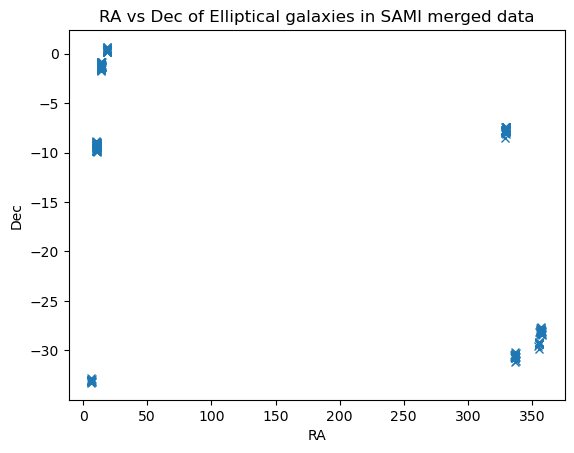

In [7]:
# let's plot the ra and dec.

ra = pd.to_numeric(ellipticals['ra_obj'], errors='coerce');
dec = pd.to_numeric(ellipticals['dec_obj'], errors='coerce');

plt.plot(
    ra,
    dec,
    'x',
    label = 'RA vs Dec',
);

plt.title('RA vs Dec of Elliptical galaxies in SAMI merged data');
plt.xlabel('RA');
plt.ylabel('Dec');
# I don't know the units.
plt.show();